# Credit Risk Analysis
German Credit Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

print('All packages imported successfully!')

All packages imported successfully!


In [2]:
df = pd.read_csv('../data/german_credit_data.csv')
print(df.shape)
df.head()


(1000, 11)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [4]:
df[['Age', 'Job', 'Credit amount', 'Duration']].describe()


,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [5]:
print(df.columns)

print(df.isnull().sum())

print(df['Risk'].value_counts())







Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64
Risk
good    700
bad     300
Name: count, dtype: int64


In [6]:
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')
print(df.isnull().sum())

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


In [7]:
df = pd.get_dummies(df, columns=['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'])
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})
df = df.drop('Unnamed: 0', axis=1)
print(df.columns)
print(df.shape)


Index(['Age', 'Job', 'Credit amount', 'Duration', 'Risk', 'Sex_female',
       'Sex_male', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Saving accounts_little', 'Saving accounts_moderate',
       'Saving accounts_quite rich', 'Saving accounts_rich',
       'Saving accounts_unknown', 'Checking account_little',
       'Checking account_moderate', 'Checking account_rich',
       'Checking account_unknown', 'Purpose_business', 'Purpose_car',
       'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others'],
      dtype='str')
(1000, 27)


In [8]:
X = df.drop('Risk', axis = 1)
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=63)
print(X_test.shape)
print(y_test.shape)

(200, 26)
(200,)


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model = LogisticRegression(random_state=63, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained successfully")



Logistic Regression trained successfully


In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=63, class_weight='balanced')
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully")

Random Forest trained successfully


In [11]:
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred_tuned = (lr_probs >= 0.78).astype(int)
print(classification_report(y_test, lr_pred_tuned))


rf_pred = rf_model.predict(X_test)
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.76      0.90      0.83       144
           1       0.52      0.27      0.35        56

    accuracy                           0.72       200
   macro avg       0.64      0.59      0.59       200
weighted avg       0.69      0.72      0.69       200

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       144
           1       0.47      0.45      0.46        56

    accuracy                           0.70       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.70      0.70      0.70       200



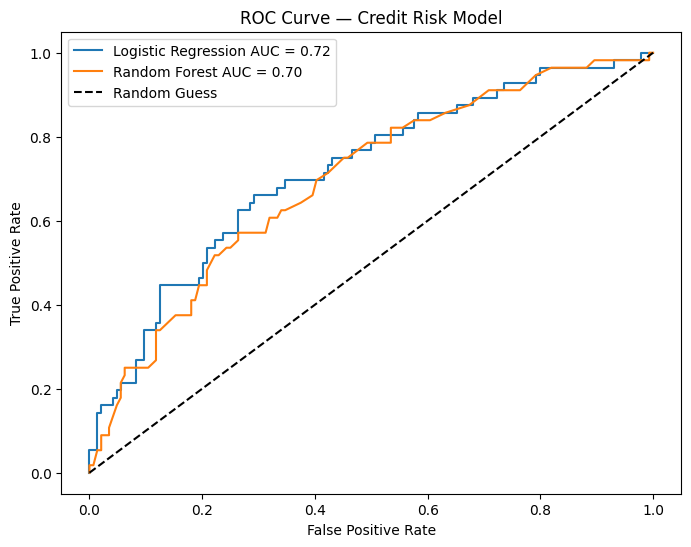

Logistic Regression AUC: 0.72
Random Forest AUC: 0.70


In [12]:
# Cell 10 — ROC Curve
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression AUC = {lr_auc:.2f}')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest AUC = {rf_auc:.2f}')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Credit Risk Model')
plt.legend()
plt.savefig('../results/roc_curve.png')
plt.show()

print(f'Logistic Regression AUC: {lr_auc:.2f}')
print(f'Random Forest AUC: {rf_auc:.2f}')

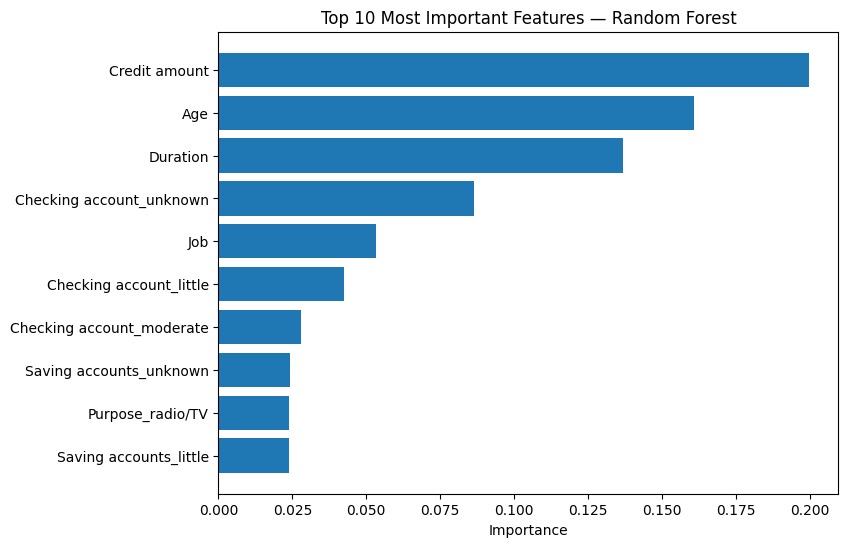

In [13]:
# Feature Importance — Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Put into a dataframe and sort
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.barh(feat_df['feature'], feat_df['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features — Random Forest')
plt.gca().invert_yaxis()
plt.savefig('../results/feature_importance.png')
plt.show()

In [17]:
xgb_model = XGBClassifier( n_estimators = 100 , random_state = 63 , eval_metric='logloss', scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum())
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print("=== XGBoost ===")
print(classification_report(y_test, xgb_pred))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       144
           1       0.49      0.55      0.52        56

    accuracy                           0.71       200
   macro avg       0.65      0.67      0.66       200
weighted avg       0.73      0.71      0.72       200

